<a href="https://colab.research.google.com/github/gorodnichenko16-cell/-/blob/main/%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BF%D0%BE_%D1%82%D0%B5%D0%BC%D0%B5_%C2%AB%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5_%D1%80%D1%8F%D0%B4%D1%8B%2C_%D0%BE%D0%B1%D1%89%D0%B0%D1%8F_%D1%82%D0%B5%D0%BE%D1%80%D0%B8%D1%8F%C2%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

def adf_test(series, title=""):
    print(f"ADF test for {title}")
    result = adfuller(series.dropna())
    print("  ADF statistic:", result[0])
    print("  p-value      :", result[1])
    for key, value in result[4].items():
        print(f"  Critical {key}: {value}")
    print()



1. monthly-sales-of-company-x-jan-6.csv

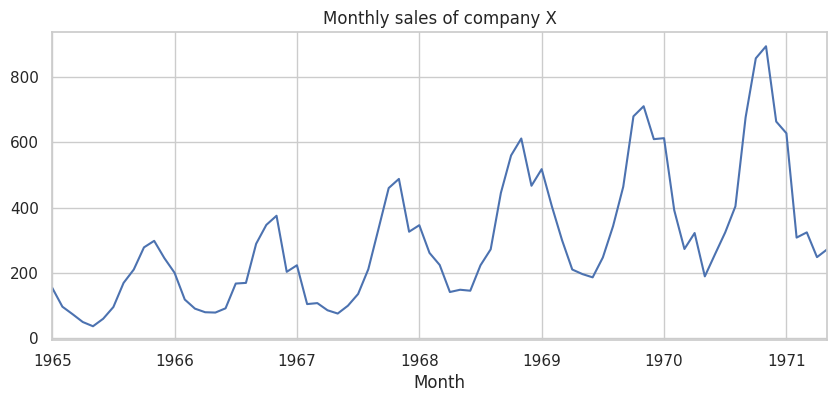

ADF test for sales (original)
  ADF statistic: 0.6547150829524446
  p-value      : 0.9888894205170052
  Critical 1%: -3.53692771987915
  Critical 5%: -2.907887369384766
  Critical 10%: -2.591493291015625



In [6]:
sales = pd.read_csv("monthly-sales-of-company-x-jan-6.csv")
sales.columns = ["Month", "Sales"]
sales["Month"] = pd.to_datetime(sales["Month"])
sales.set_index("Month", inplace=True)

ts_sales = sales["Sales"]

ts_sales.plot(title="Monthly sales of company X")
plt.show()

adf_test(ts_sales, "sales (original)")


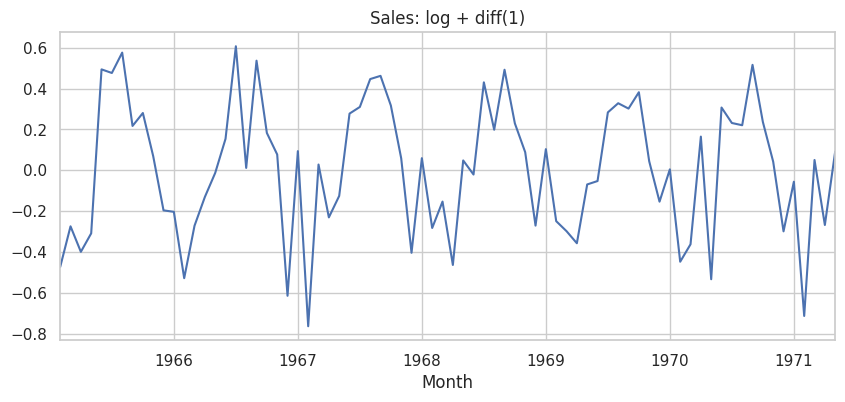

ADF test for sales (log diff 1)
  ADF statistic: -3.135643801006635
  p-value      : 0.024025392839875176
  Critical 1%: -3.53692771987915
  Critical 5%: -2.907887369384766
  Critical 10%: -2.591493291015625



In [7]:
ts_sales_log = np.log(ts_sales)
ts_sales_log_diff = ts_sales_log.diff(1).dropna()

ts_sales_log_diff.plot(title="Sales: log + diff(1)")
plt.show()

adf_test(ts_sales_log_diff, "sales (log diff 1)")


2. monthly-boston-armed-robberies-j.csv

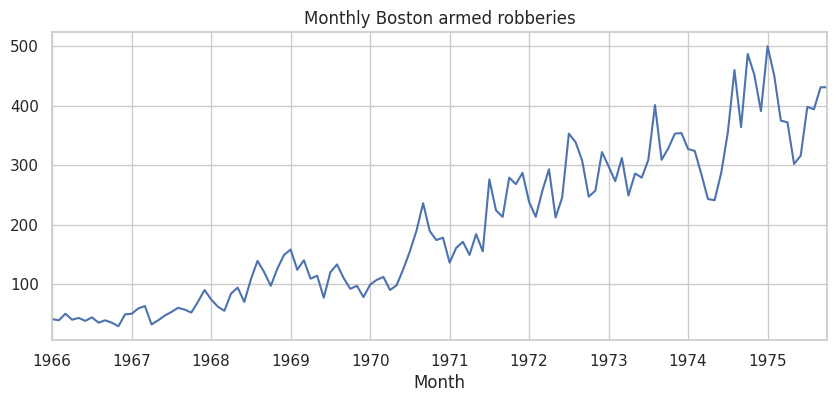

ADF test for robberies (original)
  ADF statistic: 1.001102140245781
  p-value      : 0.994277563805723
  Critical 1%: -3.4936021509366793
  Critical 5%: -2.8892174239808703
  Critical 10%: -2.58153320754717



In [8]:
rob = pd.read_csv("monthly-boston-armed-robberies-j.csv")
rob.columns = ["Month", "Robberies"]
rob["Month"] = pd.to_datetime(rob["Month"])
rob.set_index("Month", inplace=True)

ts_rob = rob["Robberies"]

ts_rob.plot(title="Monthly Boston armed robberies")
plt.show()

adf_test(ts_rob, "robberies (original)")


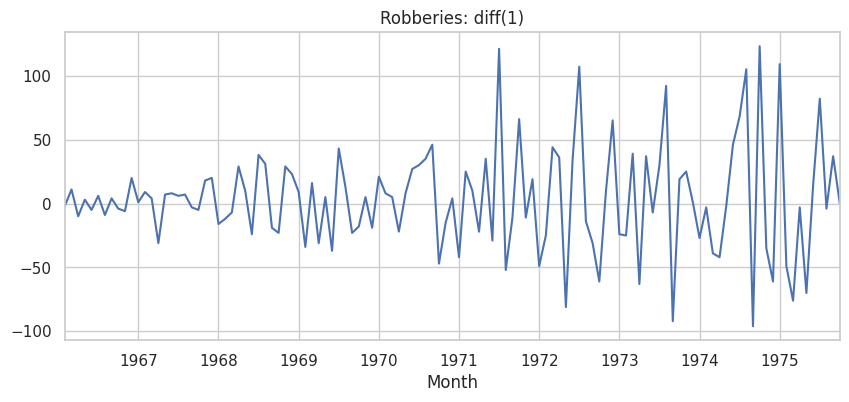

ADF test for robberies (diff 1)
  ADF statistic: -7.42856447506721
  p-value      : 6.450795412686658e-11
  Critical 1%: -3.4936021509366793
  Critical 5%: -2.8892174239808703
  Critical 10%: -2.58153320754717



In [9]:
ts_rob_diff = ts_rob.diff(1).dropna()

ts_rob_diff.plot(title="Robberies: diff(1)")
plt.show()

adf_test(ts_rob_diff, "robberies (diff 1)")


3. international-airline-passengers.csv

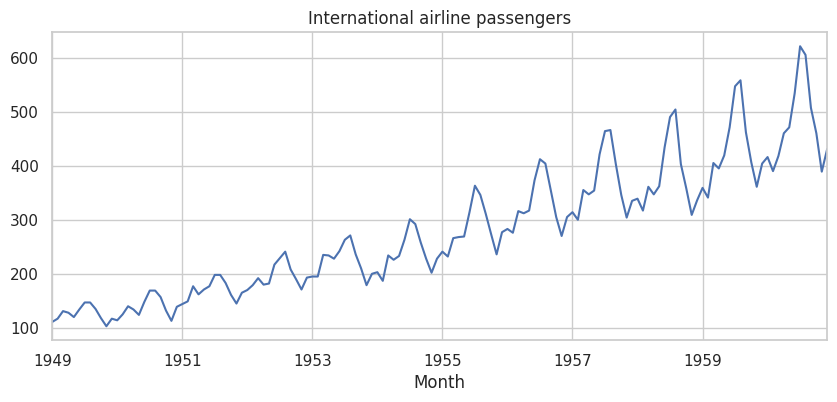

ADF test for air passengers (original)
  ADF statistic: 0.8153688792060498
  p-value      : 0.991880243437641
  Critical 1%: -3.4816817173418295
  Critical 5%: -2.8840418343195267
  Critical 10%: -2.578770059171598



In [10]:
air = pd.read_csv("international-airline-passengers.csv")
air.columns = ["Month", "Passengers"]
air["Month"] = pd.to_datetime(air["Month"])
air.set_index("Month", inplace=True)

ts_air = air["Passengers"]

ts_air.plot(title="International airline passengers")
plt.show()

adf_test(ts_air, "air passengers (original)")


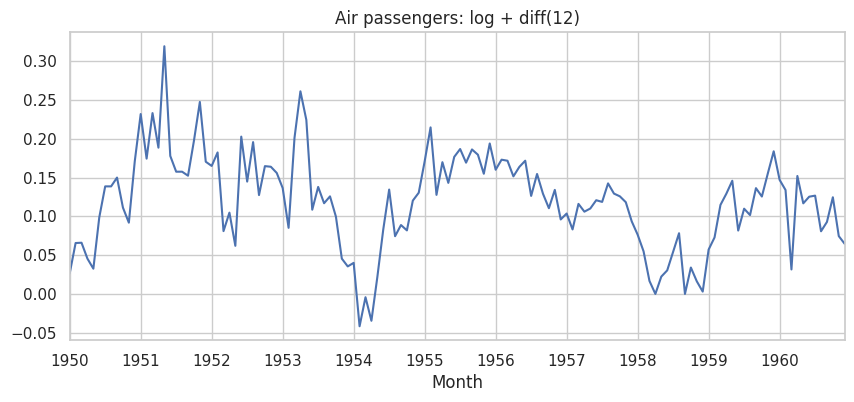

ADF test for air passengers (log diff 12)
  ADF statistic: -2.7095768189885687
  p-value      : 0.07239567181769489
  Critical 1%: -3.4865346059036564
  Critical 5%: -2.8861509858476264
  Critical 10%: -2.579896092790057



In [11]:
ts_air_log = np.log(ts_air)
ts_air_log_diff12 = ts_air_log.diff(12).dropna()

ts_air_log_diff12.plot(title="Air passengers: log + diff(12)")
plt.show()

adf_test(ts_air_log_diff12, "air passengers (log diff 12)")


4. mean-monthly-air-temperature-deg.csv

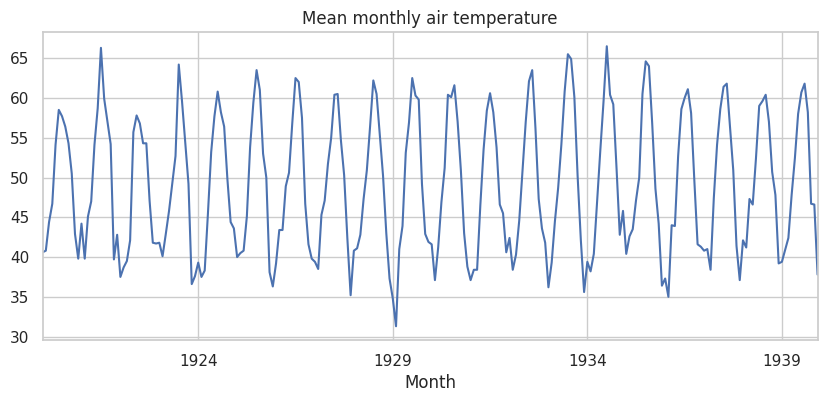

ADF test for temperature (original)
  ADF statistic: -3.2554924030863366
  p-value      : 0.016989030222608604
  Critical 1%: -3.4597521044060353
  Critical 5%: -2.874472927517147
  Critical 10%: -2.5736628197530864



In [12]:
temp = pd.read_csv("mean-monthly-air-temperature-deg.csv")
temp.columns = ["Month", "Temp"]
temp["Month"] = pd.to_datetime(temp["Month"])
temp.set_index("Month", inplace=True)

ts_temp = temp["Temp"]

ts_temp.plot(title="Mean monthly air temperature")
plt.show()

adf_test(ts_temp, "temperature (original)")


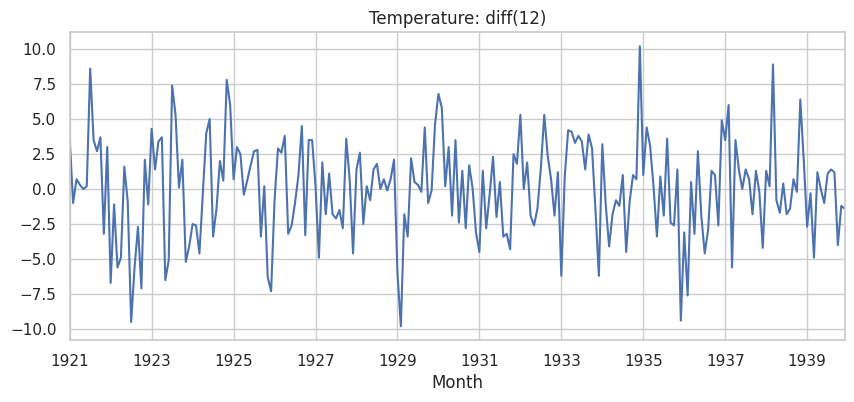

ADF test for temperature (diff 12)
  ADF statistic: -6.072500949623809
  p-value      : 1.1419453014592132e-07
  Critical 1%: -3.461136478222043
  Critical 5%: -2.875078880098608
  Critical 10%: -2.5739861168199027



In [13]:
ts_temp_diff12 = ts_temp.diff(12).dropna()

ts_temp_diff12.plot(title="Temperature: diff(12)")
plt.show()

adf_test(ts_temp_diff12, "temperature (diff 12)")


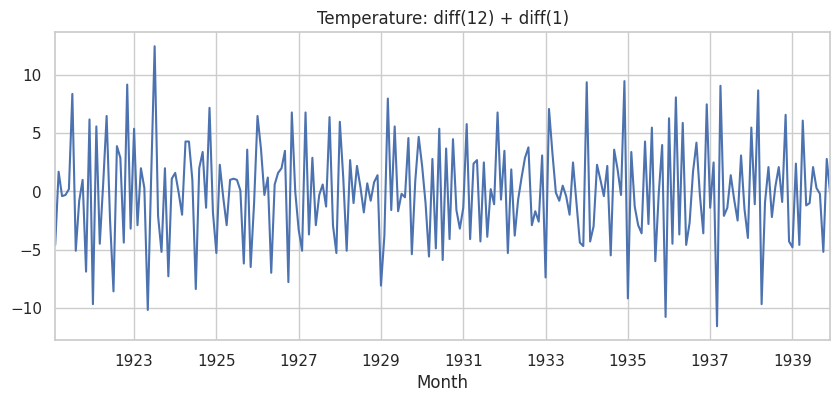

ADF test for temperature (diff 12 + diff 1)
  ADF statistic: -7.862240953056714
  p-value      : 5.2465999005979246e-12
  Critical 1%: -3.46172743446274
  Critical 5%: -2.8753374677799957
  Critical 10%: -2.574124089081557



In [14]:
ts_temp_diff12_1 = ts_temp_diff12.diff(1).dropna()

ts_temp_diff12_1.plot(title="Temperature: diff(12) + diff(1)")
plt.show()

adf_test(ts_temp_diff12_1, "temperature (diff 12 + diff 1)")


5. weekly-closings-of-the-dowjones-.csv

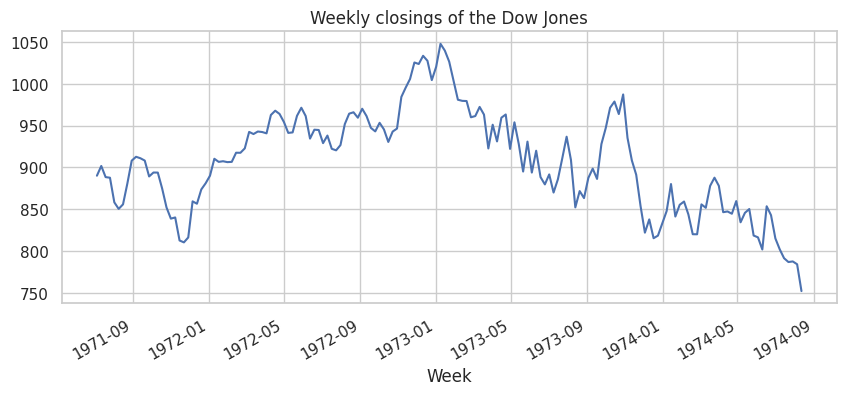

ADF test for Dow Jones (original)
  ADF statistic: -1.3146254984911683
  p-value      : 0.6224548515589733
  Critical 1%: -3.471633386932248
  Critical 5%: -2.8796651107461972
  Critical 10%: -2.576433647235832



In [16]:
dj = pd.read_csv("weekly-closings-of-the-dowjones-.csv")

if dj.shape[1] == 2:
    dj.columns = ["Week", "Price"]

    # Недели в формате 1971-W27 -> приводим к понедельнику этой недели
    dj["Week"] = pd.to_datetime(dj["Week"] + "-1", format="%Y-W%W-%w")
    dj.set_index("Week", inplace=True)
    ts_dj = dj["Price"]
else:
    dj.columns = ["Price"]
    ts_dj = dj["Price"]
    ts_dj.index = pd.RangeIndex(start=0, stop=len(ts_dj), step=1)

ts_dj.plot(title="Weekly closings of the Dow Jones")
plt.show()

adf_test(ts_dj, "Dow Jones (original)")



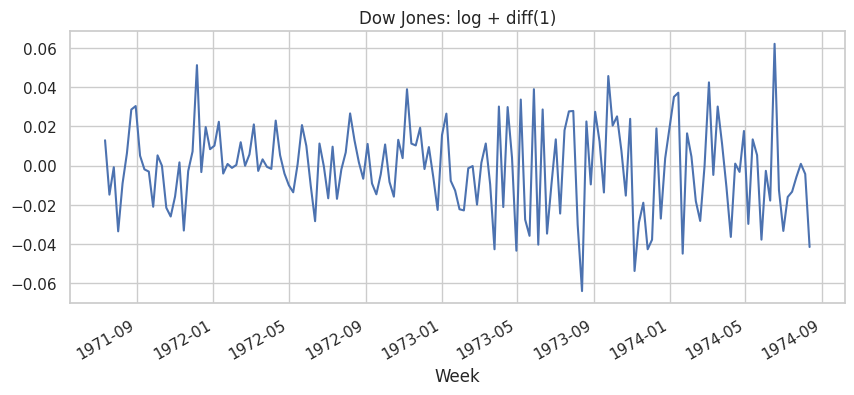

ADF test for Dow Jones (log diff 1)
  ADF statistic: -12.995820716080098
  p-value      : 2.7516091322913448e-24
  Critical 1%: -3.4718957209472654
  Critical 5%: -2.8797795410156253
  Critical 10%: -2.5764947265625



In [17]:
ts_dj_log = np.log(ts_dj)
ts_dj_log_diff = ts_dj_log.diff(1).dropna()

ts_dj_log_diff.plot(title="Dow Jones: log + diff(1)")
plt.show()

adf_test(ts_dj_log_diff, "Dow Jones (log diff 1)")


6. daily-total-female-births-in-cal.csv

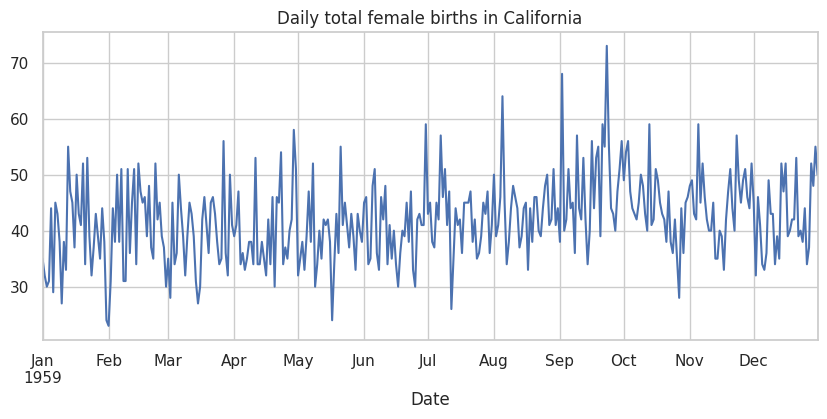

ADF test for births (original)
  ADF statistic: -4.808291253559765
  p-value      : 5.2434129901498554e-05
  Critical 1%: -3.448748905151901
  Critical 5%: -2.8696473721448728
  Critical 10%: -2.5710891239349585



In [18]:
births = pd.read_csv("daily-total-female-births-in-cal.csv")
births.columns = ["Date", "Births"]
births["Date"] = pd.to_datetime(births["Date"])
births.set_index("Date", inplace=True)

ts_births = births["Births"]

ts_births.plot(title="Daily total female births in California")
plt.show()

adf_test(ts_births, "births (original)")


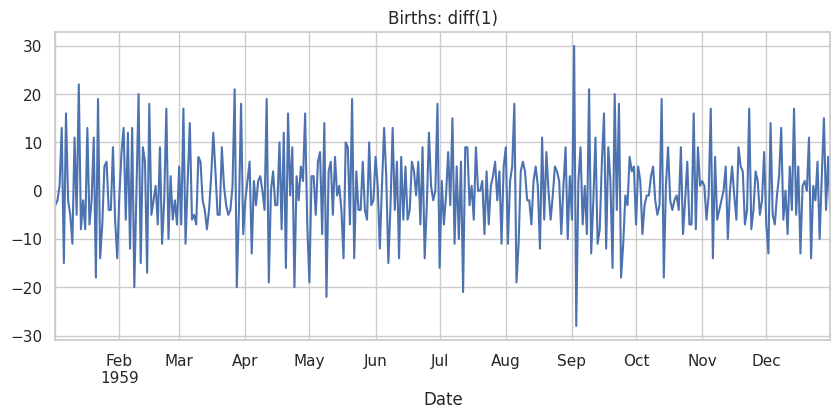

ADF test for births (diff 1)
  ADF statistic: -12.62517863387136
  p-value      : 1.5472400091968453e-23
  Critical 1%: -3.44880082033912
  Critical 5%: -2.869670179576637
  Critical 10%: -2.5711012838861036



In [19]:
ts_births_diff = ts_births.diff(1).dropna()

ts_births_diff.plot(title="Births: diff(1)")
plt.show()

adf_test(ts_births_diff, "births (diff 1)")
